# PatchTST

In [1]:
#| export
import math
import numpy as np
from typing import Optional #, Any, Tuple
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from neuralforecast.common._base_model import BaseModel
from neuralforecast.common._modules import RevIN

from neuralforecast.losses.pytorch import MAE, MSE

#| hide
import logging
import warnings
from fastcore.test import test_eq
from nbdev.showdoc import show_doc
from neuralforecast.common._model_checks import check_model

import pandas as pd
import matplotlib.pyplot as plt
from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST
from neuralforecast.losses.pytorch import DistributionLoss
from neuralforecast.utils import augment_calendar_df

In [2]:
torch.set_float32_matmul_precision('medium')

In [3]:
ett = pd.read_csv('../../ICL4DT/data/time_series_datasets/ETTm1.csv')
horizon=96
input_size=96
patch_len=16
stride=8
ett.rename({'date':'ds', 'OT':'y'}, axis=1, inplace=True)
ett['ds'] = pd.to_datetime(ett['ds'])
ett['unique_id']='ett_1'

total_window_len = input_size + horizon
ett = ett[['unique_id', 'ds', 'y']][:1000 * total_window_len].copy()
for i in range(len(ett) // total_window_len):
    start_idx = i * total_window_len
    end_idx_for_noise = start_idx + input_size - 1
    noise_to_add = np.random.normal(0, 0, size=input_size)
    ett.loc[start_idx : end_idx_for_noise, 'y'] += noise_to_add

ett, calendar_cols = augment_calendar_df(df=ett, freq='T')
Y_train_df = ett[ett.ds < ett['ds'].values[-horizon]]
Y_test_df = ett[ett.ds >= ett['ds'].values[-horizon]].reset_index(drop=True)

Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 1.5 M  | train
-----------------------------------------------------------
1.5 M     Trainable params
3         Non-trainable params
1.5 M     Total params
5.959     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=2000` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

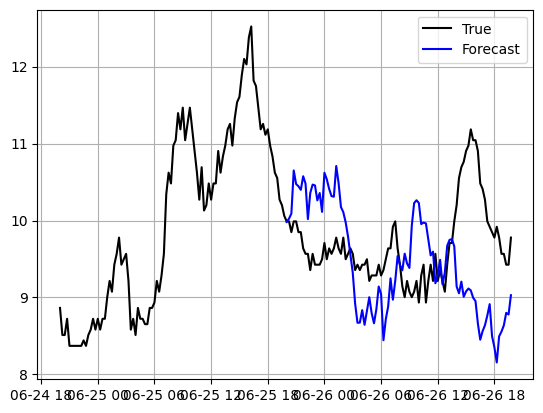

In [4]:
model = PatchTST(h=horizon,
                 input_size=input_size,
                 patch_len=patch_len,
                 stride=stride,
                 hidden_size=256,
                 n_heads=4,
                 loss=MAE(), #loss=DistributionLoss(distribution='StudentT', level=[80, 90]),
                 max_steps=2000,
                 val_check_steps=50,
                 step_size=input_size + horizon,
                 )

nf = NeuralForecast(
    models=[model],
    freq='15T'
)
nf.fit(df=Y_train_df, val_size= (input_size + horizon) * 20)
forecasts = nf.predict(futr_df=Y_test_df)

Y_hat_df = forecasts.reset_index(drop=False).drop(columns=['unique_id','ds'])
plot_df = pd.concat([Y_test_df, Y_hat_df], axis=1)
plot_df = pd.concat([Y_train_df, plot_df])

if model.loss.is_distribution_output:
    plot_df = plot_df[plot_df.unique_id=='ett_1'].drop('unique_id', axis=1)
    plt.plot(plot_df['ds'][-input_size-horizon:], plot_df['y'][-input_size-horizon:], c='black', label='True')
    plt.plot(plot_df['ds'], plot_df['PatchTST-median'], c='blue', label='median')
    plt.fill_between(x=plot_df['ds'][-horizon:], 
                    y1=plot_df['PatchTST-lo-90'][-horizon:].values, 
                    y2=plot_df['PatchTST-hi-90'][-horizon:].values,
                    alpha=0.4, label='level 90')
    plt.grid()
    plt.legend()
    plt.plot()
else:
    plot_df = plot_df[plot_df.unique_id=='ett_1'].drop('unique_id', axis=1)
    plt.plot(plot_df['ds'][-input_size-horizon:], plot_df['y'][-input_size-horizon:], c='black', label='True')
    plt.plot(plot_df['ds'], plot_df['PatchTST'], c='blue', label='Forecast')
    plt.legend()
    plt.grid()

In [5]:
ett = pd.read_csv('../../ICL4DT/data/time_series_datasets/ETTm2.csv')
ett.rename({'date':'ds', 'OT':'y'}, axis=1, inplace=True)
ett['ds'] = pd.to_datetime(ett['ds'])
ett['unique_id']='ett_1'
ett = ett[['unique_id', 'ds', 'y']]

In [6]:
def get_noised_ett(noise=0):
    total_window_len = input_size + horizon
    ett = pd.read_csv('../../ICL4DT/data/time_series_datasets/ETTm2.csv')
    ett.rename({'date':'ds', 'OT':'y'}, axis=1, inplace=True)
    ett['ds'] = pd.to_datetime(ett['ds'])
    ett['unique_id']='ett_1'
    ett = ett[['unique_id', 'ds', 'y']]
    nosied = pd.DataFrame(columns=['unique_id', 'ds', 'y'])
    for i in range(len(ett)):
        start_idx = i
        end_idx_for_noise = start_idx + input_size - 1
        noise_to_add = np.random.normal(0, noise, size=input_size)
        noised_input = ett.loc[start_idx : end_idx_for_noise, 'y'] + noise_to_add
        
    return ett

In [7]:
ett = pd.read_csv('../../ICL4DT/data/time_series_datasets/ETTm2.csv')
ett.rename({'date': 'ds', 'OT': 'y'}, axis=1, inplace=True)
ett['ds'] = pd.to_datetime(ett['ds'])
ett['unique_id'] = 'ett_1'
ett = ett[['unique_id', 'ds', 'y']]

input_size = 96
horizon = 24
noise_std_dev = 0.0

total_window_len = input_size + horizon
ett_len = len(ett)

windowed_noised_data = []

for start_idx in range(ett_len - total_window_len + 1):
    end_idx = start_idx + total_window_len
    window = ett.iloc[start_idx:end_idx].copy()
    input_indices = window.index[:input_size]
    noise = np.random.normal(0, noise_std_dev, size=input_size)
    window.loc[input_indices, 'y'] += noise
    windowed_noised_data.append(window)

final_dataset = pd.concat(windowed_noised_data, ignore_index=True)

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST
from neuralforecast.losses.pytorch import DistributionLoss
from neuralforecast.utils import augment_calendar_df
from neuralforecast.losses.numpy import mae, rmse, mape

horizon = 12
input_size = 24
patch_len = 16
stride = 8
series_freq = 'T'
num_test_windows = 500
num_plot_instances = 5
max_train_steps = 2000

def get_noised_metrics(noise_std_dev=0, test_noise_std_dev=0):

    ett = pd.read_csv('../../ICL4DT/data/time_series_datasets/ETTm2.csv')
    ett.rename({'date':'ds', 'OT':'y'}, axis=1, inplace=True)
    ett['ds'] = pd.to_datetime(ett['ds'])
    ett['unique_id']='ett_1'
    ett = ett[['unique_id', 'ds', 'y']]
    ett = ett[:2500 * (input_size + horizon)]
    ett, calendar_cols = augment_calendar_df(df=ett, freq=series_freq)
    total_window_len = input_size + horizon
    test_set_size = num_test_windows * total_window_len
    split_point = len(ett) - test_set_size
    train_val_df_original = ett.iloc[:split_point].copy()
    Y_test_df_clean = ett.iloc[split_point:].reset_index(drop=True).copy()
    Y_train_val_df_noised = train_val_df_original.copy()
    num_blocks_in_train_val = len(Y_train_val_df_noised) // total_window_len

    for i in range(num_blocks_in_train_val):
        start_idx_in_block = i * total_window_len
        noise_start_loc = Y_train_val_df_noised.index[start_idx_in_block]
        noise_end_loc = Y_train_val_df_noised.index[start_idx_in_block + input_size - 1]
        noise_to_add = np.random.normal(0, noise_std_dev, size=input_size)
        Y_train_val_df_noised.loc[noise_start_loc : noise_end_loc, 'y'] += noise_to_add

    for i in range(num_test_windows):
        start_idx_in_block = i * total_window_len
        noise_start_loc = Y_test_df_clean.index[start_idx_in_block]
        noise_end_loc = Y_test_df_clean.index[start_idx_in_block + input_size - 1]
        noise_to_add = np.random.normal(0, test_noise_std_dev, size=input_size)
        Y_test_df_clean.loc[noise_start_loc : noise_end_loc, 'y'] += noise_to_add

    model = PatchTST(h=horizon,
                    input_size=input_size,
                    patch_len=patch_len,
                    stride=stride,
                    hidden_size=16,
                    n_heads=4,
                    loss=MAE(),
                    max_steps=max_train_steps,
                    step_size=input_size + horizon,
                    )

    nf = NeuralForecast(
        models=[model],
        freq="15T"
    )

    nf.fit(df=Y_train_val_df_noised, val_size=0)
    test_ids = [f'ett_{i}' for i in range(len(Y_test_df_clean) // (input_size + horizon))]
    test_ids = [np.repeat(test_ids[i], (input_size + horizon)) for i in range(len(test_ids))]
    Y_test_df_clean['unique_id'] = np.concatenate(test_ids)
    Y_test_inputs_df = Y_test_df_clean.groupby('unique_id').head(input_size).reset_index(drop=True)
    Y_test_outputs_df = Y_test_df_clean.groupby('unique_id').tail(horizon).reset_index(drop=True)
    forecasts = nf.predict(df=Y_test_inputs_df)
    model_output_col = 'PatchTST'
    preds = forecasts.merge(Y_test_outputs_df, on=['unique_id', 'ds'], how='inner')
    preds['mse'] = (preds['y'] - preds[model_output_col]) ** 2
    preds['mae'] = abs(preds['y'] - preds[model_output_col])
    preds['mse'] = preds['mse'].mean()
    preds['mae'] = preds['mae'].mean()
    print(f"MSE: {preds['mse'].values[0]}")
    print(f"MAE: {preds['mae'].values[0]}")
    test_tensor_segments = []
    sorted_unique_test_ids_for_tensor = []
    unique_ids_from_inputs = Y_test_inputs_df['unique_id'].unique()
    sorted_unique_test_ids_for_tensor = sorted(unique_ids_from_inputs, key=lambda x: int(x.split('_')[-1]))
    forecasts_raw_with_cols = forecasts.reset_index() if not ('unique_id' in forecasts.columns and model_output_col in forecasts.columns) else forecasts

    for uid in sorted_unique_test_ids_for_tensor:
        input_y_values = Y_test_inputs_df[Y_test_inputs_df['unique_id'] == uid]['y'].values
        forecast_y_values = forecasts_raw_with_cols[forecasts_raw_with_cols['unique_id'] == uid][model_output_col].values

        if len(input_y_values) == input_size and len(forecast_y_values) == horizon:
            combined_segment = np.concatenate((input_y_values, forecast_y_values))
            test_tensor_segments.append(combined_segment)
            
    stacked_segments = np.stack(test_tensor_segments, axis=0)
    output_tensor = np.expand_dims(stacked_segments, axis=0)

    return preds['mse'].values[0], preds['mae'].values[0], output_tensor

In [9]:
mse, mae, tensor = get_noised_metrics(noise_std_dev=0, test_noise_std_dev=0)

Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 29.8 K | train
-----------------------------------------------------------
29.8 K    Trainable params
3         Non-trainable params
29.8 K    Total params
0.119     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=2000` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

MSE: 1.9754306140021622
MAE: 0.7837694420139305


In [10]:
mses = []
maes = []
tensors = []

for noise in [0,1,2,3,4,5]:
    mse, mae, tensor = get_noised_metrics(noise_std_dev=noise, test_noise_std_dev=0)
    mses.append(mse)
    maes.append(mae)
    tensors.append(tensor)

combined_tensor = np.concatenate(tensors, axis=0)

Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 29.8 K | train
-----------------------------------------------------------
29.8 K    Trainable params
3         Non-trainable params
29.8 K    Total params
0.119     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=2000` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

MSE: 7.360768221388433
MAE: 1.9177085917680525


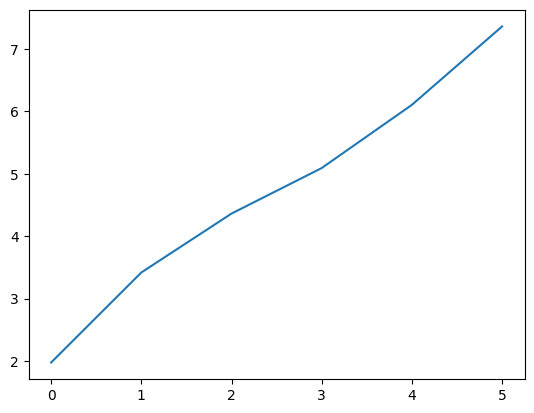

In [11]:
plt.plot(mses)

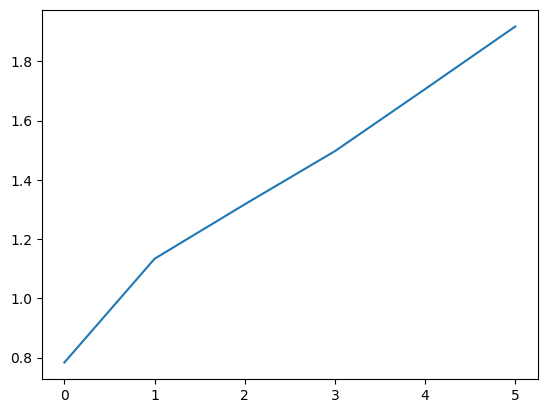

In [12]:
plt.plot(maes)

In [14]:
#convert tensor to torch
import torch

torch_data = torch.tensor(combined_tensor, dtype=torch.float32)
torch.save(torch_data, 'ett_forecasts_more_noise.pt')

In [15]:
#get the max value in torch_data
torch_data.min()

tensor(-3.4444)

In [16]:
combined_tensor.shape

(6, 500, 36)

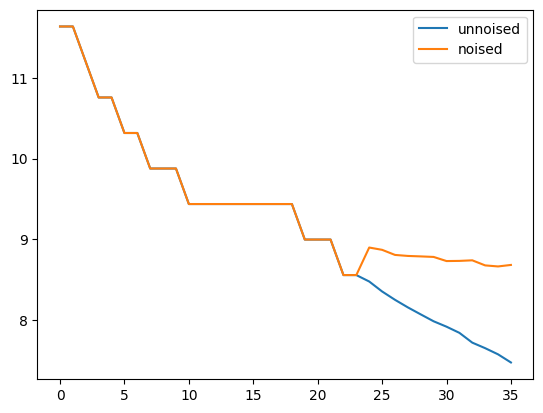

In [39]:
noise = 4
i=2
plt.plot(combined_tensor[0, i, :], label='unnoised')
plt.plot(combined_tensor[noise, i, :], label='noised')
plt.legend()


In [40]:
combined_tensor = combined_tensor[[0,1,2,3,4]]

In [43]:
combined_tensor.shape

(5, 500, 36)

In [47]:
torch_data = torch.tensor(combined_tensor, dtype=torch.float32)
torch.save(torch_data, 'ett_forecasts_rebuttals.pt')

In [48]:
torch_data.shape

torch.Size([5, 500, 36])

In [49]:
# for the first 5 unique_ids, plot the  input size + horizon for y from Y_test_inputs_df and Y_test_outputs_df, and just the horizon for PatchTST from preds
for i in range(num_plot_instances):
    unique_id = preds['unique_id'].unique()[i]
    Y_test_inputs_df_unique = Y_test_inputs_df[Y_test_inputs_df['unique_id'] == unique_id]
    Y_test_outputs_df_unique = Y_test_outputs_df[Y_test_outputs_df['unique_id'] == unique_id]
    preds_unique = preds[preds['unique_id'] == unique_id]

    plt.figure(figsize=(12, 6))
    plt.plot(Y_test_inputs_df_unique['ds'], Y_test_inputs_df_unique['y'], label='Input', color='blue')
    plt.plot(Y_test_outputs_df_unique['ds'], Y_test_outputs_df_unique['y'], label='True Output', color='black')
    plt.plot(preds_unique['ds'], preds_unique['PatchTST'], label='Predicted Output', color='red')
    plt.title(f'Unique ID: {unique_id}')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

NameError: name 'preds' is not defined

In [221]:
data = pd.read_csv('../../ICL4DT/data/time_series_datasets/ETTm2.csv')

In [222]:
data

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,41.130001,12.481,36.535999,9.355,4.424,1.311,38.661999
1,2016-07-01 00:15:00,39.622002,11.309,35.543999,8.551,3.209,1.258,38.223000
2,2016-07-01 00:30:00,38.868000,10.555,34.365002,7.586,4.435,1.258,37.344002
3,2016-07-01 00:45:00,35.518002,9.214,32.569000,8.712,4.435,1.215,37.124001
4,2016-07-01 01:00:00,37.528000,10.136,33.936001,7.532,4.435,1.215,37.124001
...,...,...,...,...,...,...,...,...
69675,2018-06-26 18:45:00,42.722000,12.230,54.014000,12.652,-11.525,-1.418,45.986500
69676,2018-06-26 19:00:00,38.868000,10.052,49.859001,10.669,-11.525,-1.418,45.986500
69677,2018-06-26 19:15:00,39.622002,11.057,50.448002,11.795,-10.299,-1.418,45.546501
69678,2018-06-26 19:30:00,40.459999,11.392,51.841999,11.929,-11.536,-1.418,45.546501
